# Customer Intelligence System: Country Segmentation for HELP International

## Project Overview
This notebook builds an end-to-end **Customer Intelligence System** combining:
- **Clustering** (K-Means, DBSCAN) to segment countries by socio-economic/health development
- **Classification** (Random Forest, XGBoost) trained on the cluster-derived labels, enabling new/unseen countries to be categorized automatically
- **Actionable insights** for HELP International on which countries most need the $10M aid

### Workflow
1. Load & inspect data
2. Clean & preprocess
3. EDA (correlations, distributions)
4. Scale features
5. K-Means (elbow + silhouette) and DBSCAN clustering
6. PCA visualization
7. Derive a "Development Category" label from cluster profiles
8. Train Random Forest & XGBoost classifiers on this label
9. Evaluate classifiers (accuracy, F1, confusion matrix, feature importance)
10. Final insights & aid-priority country list


## 1) Install & Import Libraries

In [1]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn xgboost

In [2]:
import os
os.environ['OMP_NUM_THREADS'] = '1'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              accuracy_score, f1_score)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

sns.set(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

## 2) Load the Dataset

Place `Country-data.csv` in the same directory as this notebook (or update the path below).

In [3]:
df = pd.read_csv('Country-data.csv')
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 3) Quick Inspection

In [4]:
print('Shape:', df.shape)
display(df.head())
display(df.info())
display(df.describe().T)

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


None

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


## 4) Expected Columns

| Column | Description |
|---|---|
| country | Name of the country |
| child_mort | Deaths of children under 5 per 1000 live births |
| exports | Exports of goods/services per capita (% of GDP per capita) |
| health | Total health spending per capita (% of GDP per capita) |
| imports | Imports of goods/services per capita (% of GDP per capita) |
| income | Net income per person |
| inflation | Annual growth rate of Total GDP |
| life_expec | Average life expectancy (years) |
| total_fer | Total fertility rate (children per woman) |
| gdpp | GDP per capita |


In [5]:
print('Columns:', df.columns.tolist())

Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


## 5) Basic Cleaning

In [6]:
df = df.copy()
df.columns = [c.strip().lower() for c in df.columns]
df = df.drop_duplicates()

numeric_cols = [c for c in df.columns if c != 'country']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print('Missing values after cleaning:')
display(df.isna().sum())
print('Shape after cleaning:', df.shape)

Missing values after cleaning:


country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Shape after cleaning: (167, 10)


## 6) Exploratory Data Analysis

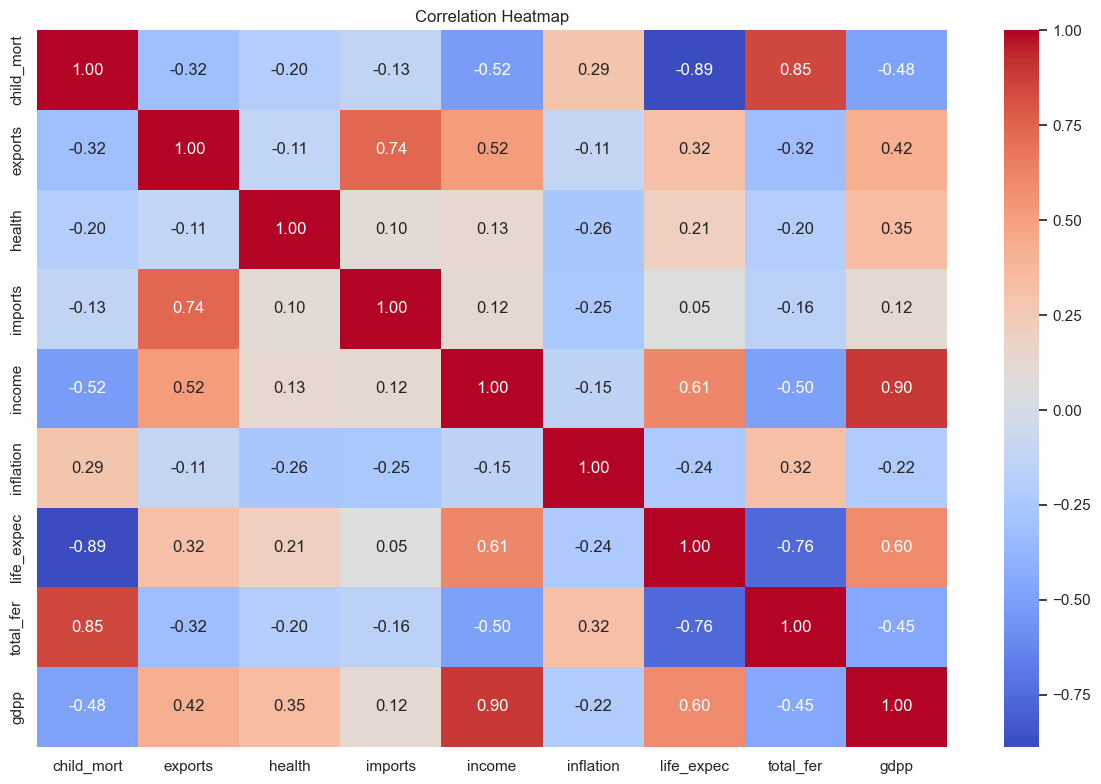

In [7]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Observations:** `child_mort` and `total_fer` are strongly positively correlated, while `life_expec`, `income`, and `gdpp` tend to move together. `income` and `gdpp` are highly correlated, as expected.

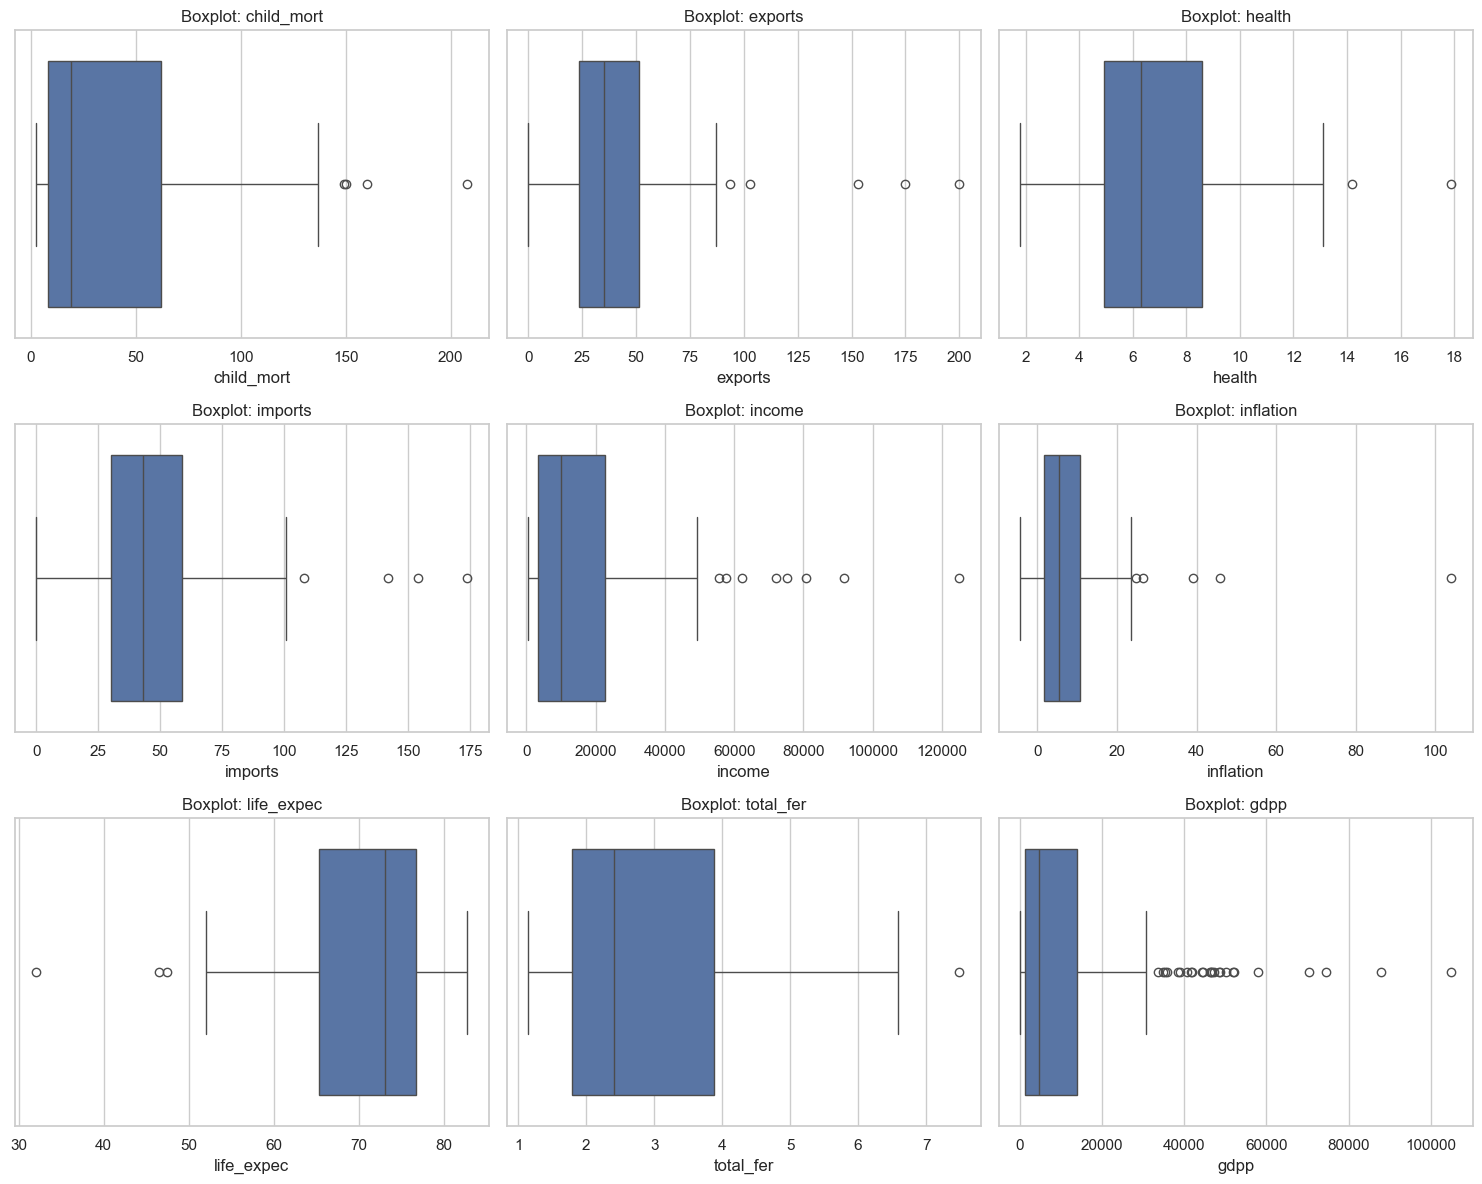

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()

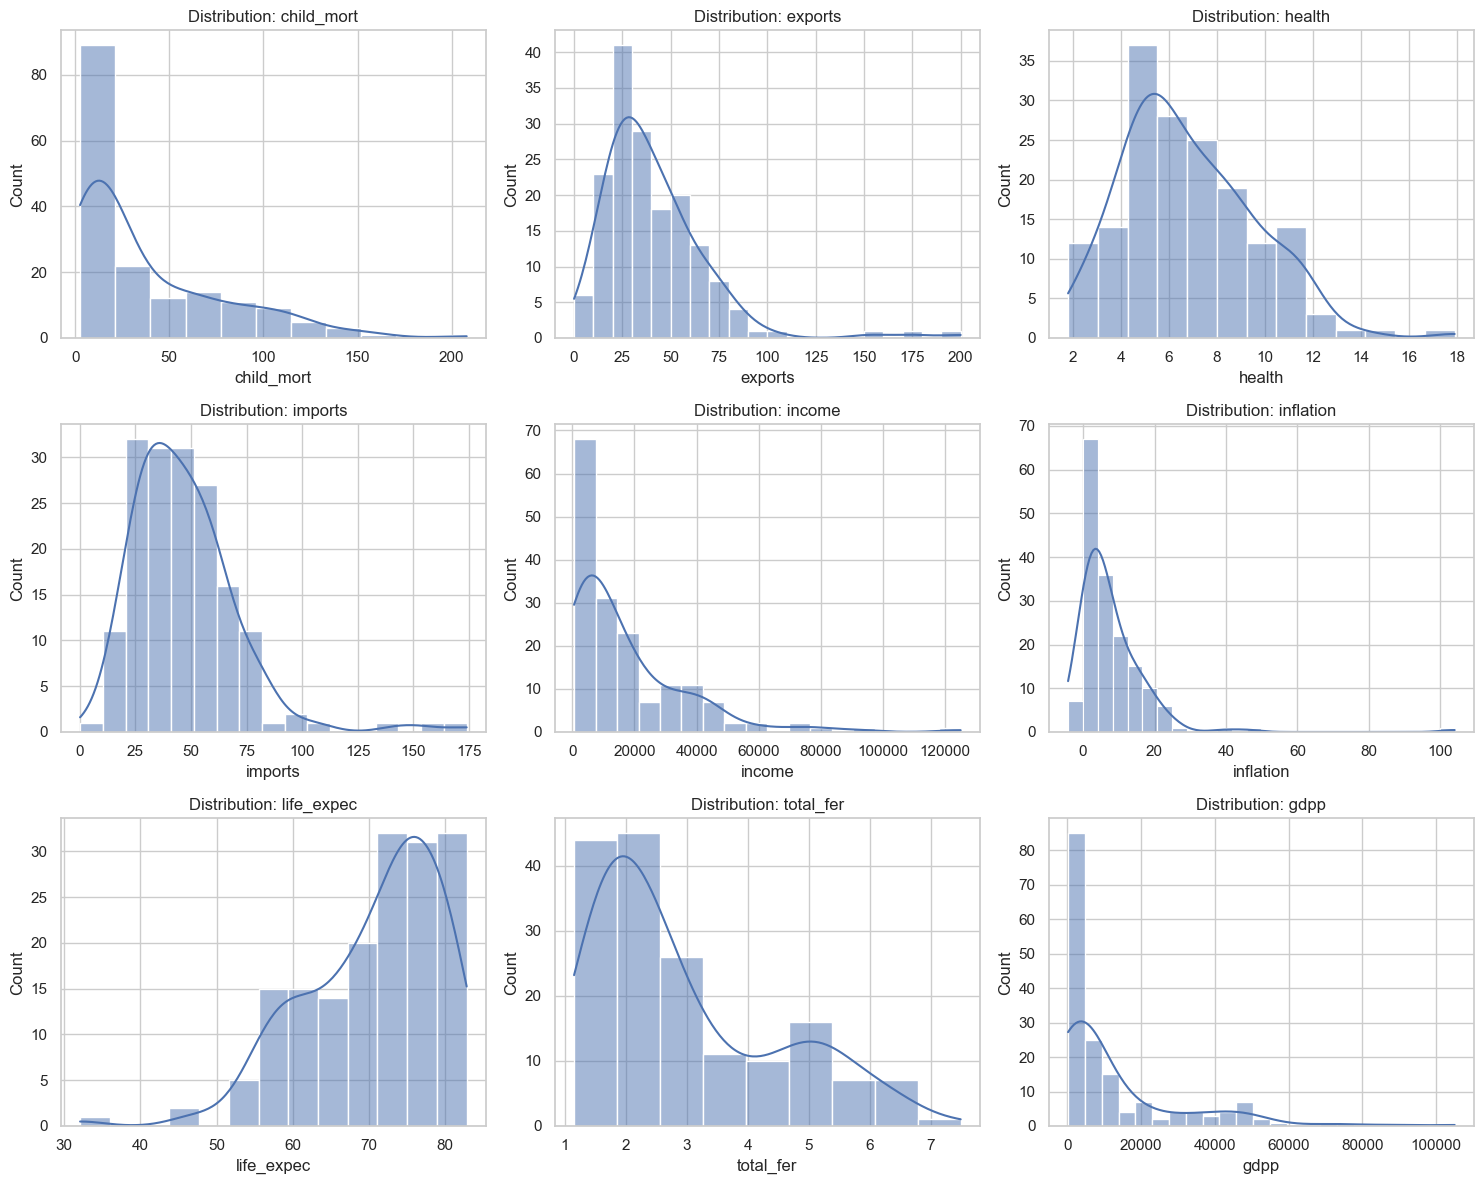

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f'Distribution: {col}')
plt.tight_layout()
plt.show()

## 7) Feature Scaling

In [10]:
features = df[numeric_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
X_scaled.shape

(167, 9)

## 8) K-Means: Elbow Method & Silhouette Score

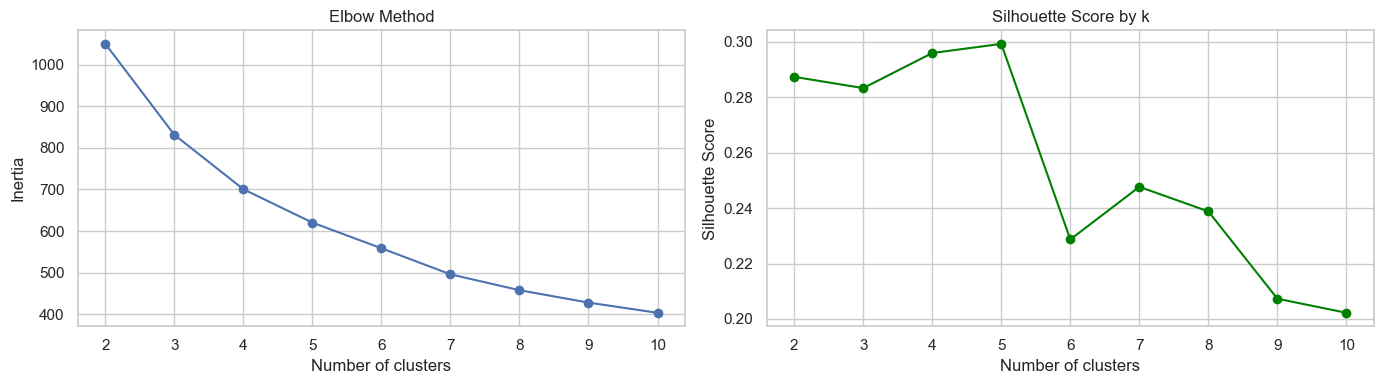

k=2: silhouette=0.2874
k=3: silhouette=0.2833
k=4: silhouette=0.2960
k=5: silhouette=0.2993
k=6: silhouette=0.2287
k=7: silhouette=0.2477
k=8: silhouette=0.2388
k=9: silhouette=0.2073
k=10: silhouette=0.2022


In [11]:
inertias = []
sil_scores = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(list(k_values), inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of clusters')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_values), sil_scores, marker='o', color='green')
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('Number of clusters')
axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

for k, s in zip(k_values, sil_scores):
    print(f'k={k}: silhouette={s:.4f}')

**Choice of k:** Based on the elbow curve flattening and silhouette scores, **k=3** gives a clean, interpretable, business-relevant segmentation (roughly: developed, developing, underdeveloped) and is used below.

## 9) Train K-Means (Final Model)

In [12]:
best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print('Silhouette Score:', silhouette_score(X_scaled, df['kmeans_cluster']))
print(df['kmeans_cluster'].value_counts())
df[['country', 'kmeans_cluster']].head()

Silhouette Score: 0.28329575683463126
kmeans_cluster
2    84
1    47
0    36
Name: count, dtype: int64


,country,kmeans_cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2


## 10) DBSCAN (Density-Based Clustering)

In [13]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print(df['dbscan_cluster'].value_counts().sort_index())
print('\nNote: cluster label -1 = noise/outlier points (countries with unusual profiles)')

dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64

Note: cluster label -1 = noise/outlier points (countries with unusual profiles)


## 11) PCA Visualization

Explained variance ratio: [0.4595174  0.17181626]


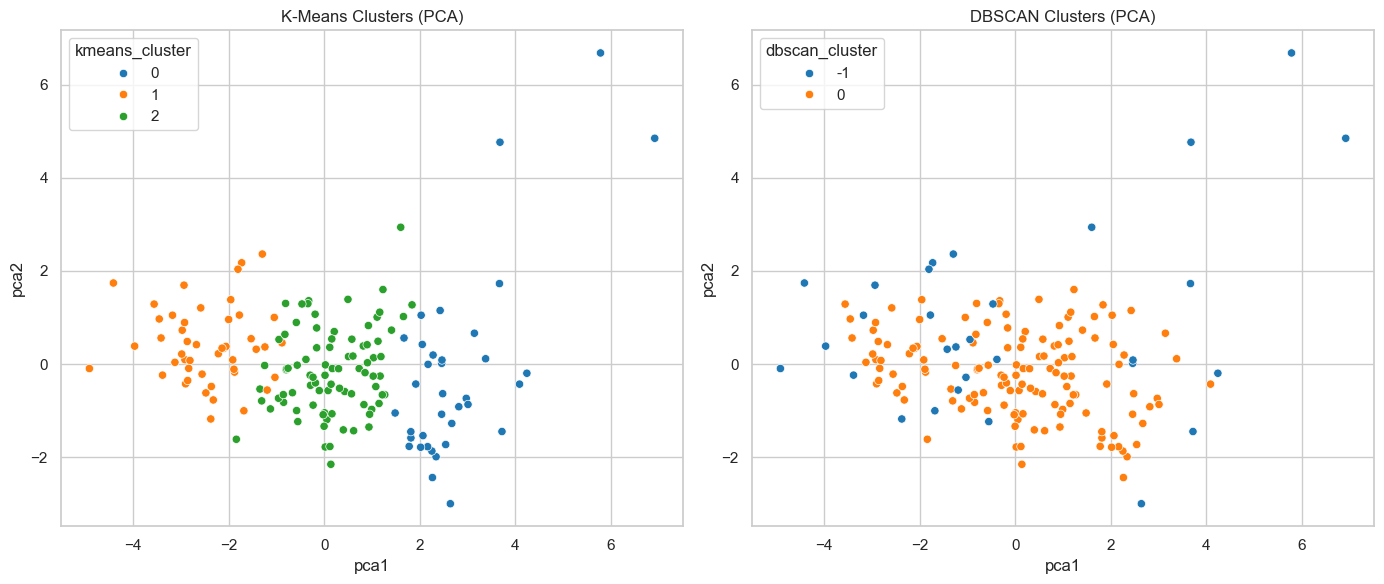

In [14]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print('Explained variance ratio:', pca.explained_variance_ratio_)

viz = pd.DataFrame({
    'pca1': X_pca[:, 0],
    'pca2': X_pca[:, 1],
    'kmeans_cluster': df['kmeans_cluster'],
    'dbscan_cluster': df['dbscan_cluster']
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(data=viz, x='pca1', y='pca2', hue='kmeans_cluster', palette='tab10', ax=axes[0])
axes[0].set_title('K-Means Clusters (PCA)')

sns.scatterplot(data=viz, x='pca1', y='pca2', hue='dbscan_cluster', palette='tab10', ax=axes[1])
axes[1].set_title('DBSCAN Clusters (PCA)')
plt.tight_layout()
plt.show()

## 12) Cluster Profiling

In [15]:
profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


## 13) Deriving a Development Category Label

We rank the K-Means clusters using key development indicators (`gdpp`, `income`, `life_expec` — higher is better; `child_mort` — lower is better) to assign each cluster a business-meaningful label: **High Need**, **Medium Need**, or **Low Need**. This derived label becomes the **target variable** for our classification models.

In [16]:
rank_df = profile[['gdpp', 'income', 'life_expec', 'child_mort']].copy()
rank_df['dev_score'] = (rank_df['gdpp'].rank() + rank_df['income'].rank()
                         + rank_df['life_expec'].rank() - rank_df['child_mort'].rank())

ordered_clusters = rank_df['dev_score'].sort_values().index.tolist()
category_names = ['High Need', 'Medium Need', 'Low Need']
label_map = {cluster: category_names[i] for i, cluster in enumerate(ordered_clusters)}

print('Cluster -> Category mapping:', label_map)

df['development_category'] = df['kmeans_cluster'].map(label_map)
df['development_category'].value_counts()

Cluster -> Category mapping: {1: 'High Need', 2: 'Medium Need', 0: 'Low Need'}


development_category
Medium Need    84
High Need      47
Low Need       36
Name: count, dtype: int64

## 14) Classification: Random Forest & XGBoost

We train classifiers to predict a country's `development_category` from its socio-economic/health features. This allows the same pipeline to score *new* countries without re-running clustering.

In [17]:
X = df[numeric_cols]
y = df['development_category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)

Train shape: (133, 9)  Test shape: (34, 9)


### 14a) Random Forest

In [18]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print('Random Forest Accuracy:', accuracy_score(y_test, rf_pred))
print('Random Forest F1 (weighted):', f1_score(y_test, rf_pred, average='weighted'))
print()
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 1.0
Random Forest F1 (weighted): 1.0

              precision    recall  f1-score   support

   High Need       1.00      1.00      1.00        10
    Low Need       1.00      1.00      1.00         7
 Medium Need       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



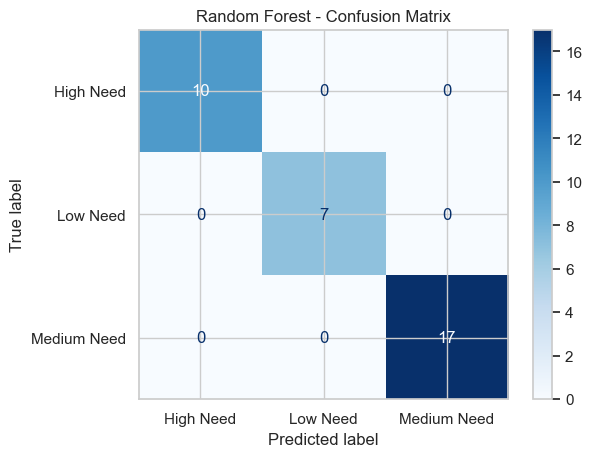

In [19]:
cm = confusion_matrix(y_test, rf_pred, labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.show()

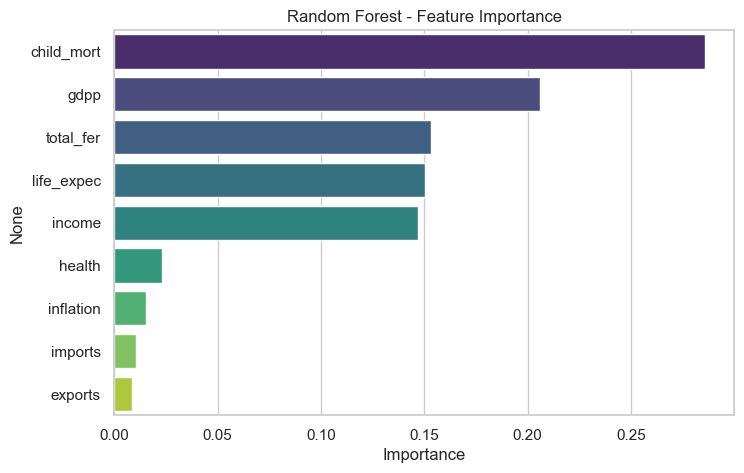

In [20]:
rf_importances = pd.Series(rf.feature_importances_, index=numeric_cols).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=rf_importances.values, y=rf_importances.index, hue=rf_importances.index,
            palette='viridis', legend=False)
plt.title('Random Forest - Feature Importance')
plt.xlabel('Importance')
plt.show()

### 14b) XGBoost

In [21]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb_model = XGBClassifier(n_estimators=200, random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train_enc)
xgb_pred_enc = xgb_model.predict(X_test)
xgb_pred = le.inverse_transform(xgb_pred_enc)

print('XGBoost Accuracy:', accuracy_score(y_test, xgb_pred))
print('XGBoost F1 (weighted):', f1_score(y_test, xgb_pred, average='weighted'))
print()
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 1.0
XGBoost F1 (weighted): 1.0

              precision    recall  f1-score   support

   High Need       1.00      1.00      1.00        10
    Low Need       1.00      1.00      1.00         7
 Medium Need       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



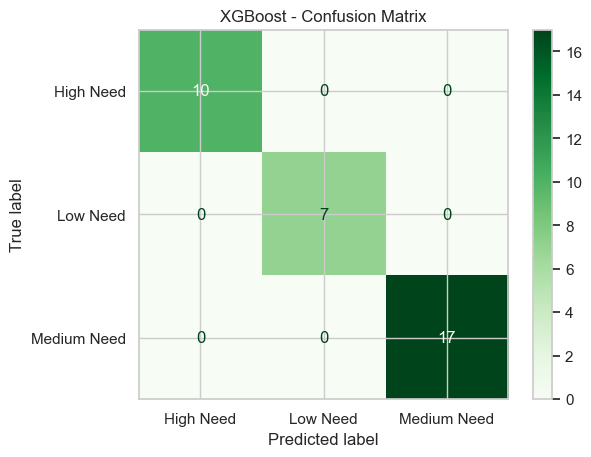

In [22]:
cm_xgb = confusion_matrix(y_test, xgb_pred, labels=le.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=le.classes_)
disp.plot(cmap='Greens')
plt.title('XGBoost - Confusion Matrix')
plt.show()

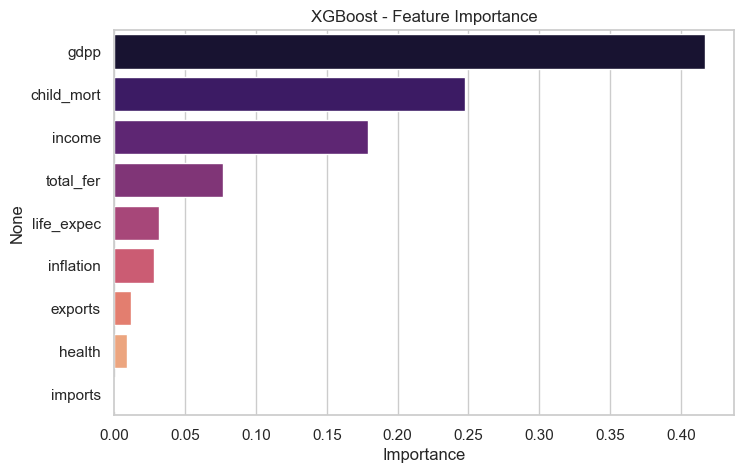

In [23]:
xgb_importances = pd.Series(xgb_model.feature_importances_, index=numeric_cols).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=xgb_importances.values, y=xgb_importances.index, hue=xgb_importances.index,
            palette='magma', legend=False)
plt.title('XGBoost - Feature Importance')
plt.xlabel('Importance')
plt.show()

### 14c) Model Comparison

In [24]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_score(y_test, rf_pred), accuracy_score(y_test, xgb_pred)],
    'F1 (weighted)': [f1_score(y_test, rf_pred, average='weighted'),
                       f1_score(y_test, xgb_pred, average='weighted')]
})
comparison

,Model,Accuracy,F1 (weighted)
0,Random Forest,1.0,1.0
1,XGBoost,1.0,1.0


## 15) Final Insights & Aid-Priority Countries

**Key observations:**

1. **High Need cluster** has the highest `child_mort` and `total_fer`, and the lowest `income`, `gdpp`, and `life_expec` — these are countries with the weakest socio-economic and health indicators.
2. **Low Need cluster** has high `income`, `gdpp`, `life_expec`, and very low `child_mort` — these correspond to developed economies.
3. **Medium Need cluster** sits in between, showing moderate development across most indicators.
4. Feature importance from both Random Forest and XGBoost consistently highlights `child_mort`, `income`, and `gdpp` as the strongest predictors of development category — confirming these are the most actionable indicators for aid targeting.
5. **DBSCAN** flags a small set of outlier countries (label `-1`) with unusual combinations of indicators (e.g., very high inflation or very low health spending relative to peers) that may warrant individual review.

**Recommendation for HELP International:** Prioritize the **High Need** countries (lowest `gdpp`/`income`, highest `child_mort`) for the $10M aid allocation. The classifier can be reused to automatically score future/updated country data into these categories.

In [25]:
priority_countries = df[df['development_category'] == 'High Need'] \
    .sort_values(['gdpp', 'income', 'child_mort'], ascending=[True, True, False])

print(f"Number of High Need countries: {len(priority_countries)}")
priority_countries[['country', 'child_mort', 'income', 'gdpp', 'life_expec', 'total_fer']].head(15)

Number of High Need countries: 47


,country,child_mort,income,gdpp,life_expec,total_fer
26,Burundi,93.6,764,231,57.7,6.26
88,Liberia,89.3,700,327,60.8,5.02
37,"Congo, Dem. Rep.",116.0,609,334,57.5,6.54
112,Niger,123.0,814,348,58.8,7.49
132,Sierra Leone,160.0,1220,399,55.0,5.20
93,Madagascar,62.2,1390,413,60.8,4.60
106,Mozambique,101.0,918,419,54.5,5.56
31,Central African Republic,149.0,888,446,47.5,5.21
94,Malawi,90.5,1030,459,53.1,5.31
50,Eritrea,55.2,1420,482,61.7,4.61
